<a href="https://colab.research.google.com/github/DEATHorGOD/aodv-pr-ect-hcmut/blob/main/Speech_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Bước 1: Cài đặt thư viện và Tải Dataset

In [1]:

# 1. Cài đặt các thư viện cần thiết
!pip install librosa soundfile fastai natsort

import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fastai.vision.all import *

# 2. Tải Dataset RAVDESS (Link trực tiếp)
if not os.path.exists('ravdess_data'):
    !wget -O ravdess.zip https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1
    !unzip -q ravdess.zip -d ravdess_data
    print("Đã tải và giải nén xong dataset!")

###Bước 2: Chuyển đổi Audio thành Hình ảnh (Mel-Spectrogram)

In [2]:
# Cấu trúc thư mục để FastAI đọc được
os.makedirs('data_images/train', exist_ok=True)

# Từ điển nhãn RAVDESS
emotion_dict = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

def create_spectrogram(audio_path, output_path):
    y, sr = librosa.load(audio_path, duration=3)
    yt, _ = librosa.effects.trim(y)
    spec = librosa.feature.melspectrogram(y=yt, sr=sr, n_fft=1024, hop_length=512)
    spec_db = librosa.power_to_db(spec, ref=np.max)

    # Vẽ ảnh không có viền/trục để AI học tốt hơn
    plt.figure(figsize=(2, 2))
    librosa.display.specshow(spec_db, sr=sr)
    plt.axis('off')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

# Duyệt qua các file audio và tạo ảnh
print("Đang tạo ảnh từ âm thanh (có thể mất vài phút)...")
audio_files = get_files('ravdess_data', extensions=['.wav'])

for audio_path in audio_files:
    file_name = os.path.basename(audio_path)
    parts = file_name.split('-')
    if len(parts) > 2:
        emotion = emotion_dict[parts[2]]
        label_dir = Path('data_images/train') / emotion
        os.makedirs(label_dir, exist_ok=True)

        output_image = label_dir / (file_name.replace('.wav', '.jpg'))
        if not output_image.exists():
            create_spectrogram(audio_path, output_image)

print("Đã chuyển đổi xong toàn bộ sang hình ảnh!")

Đang tạo ảnh từ âm thanh (có thể mất vài phút)...
Đã chuyển đổi xong toàn bộ sang hình ảnh!


 2.1. Kiểm tra cấu trúc thư mục và số lượng hình ảnh đã tạo

In [3]:
from pathlib import Path

image_dir = Path('data_images/train')

print("Các thư mục cảm xúc đã tạo:")
for emotion_folder in image_dir.iterdir():
    if emotion_folder.is_dir():
        num_images = len(list(emotion_folder.glob('*.jpg')))
        print(f"- {emotion_folder.name}: {num_images} hình ảnh")

if not list(image_dir.iterdir()):
    print("Chưa có thư mục cảm xúc nào được tạo. Có thể quá trình tạo ảnh chưa hoàn tất hoặc gặp lỗi.")

Các thư mục cảm xúc đã tạo:
- neutral: 96 hình ảnh
- sad: 192 hình ảnh
- angry: 192 hình ảnh
- calm: 192 hình ảnh
- happy: 192 hình ảnh
- fearful: 192 hình ảnh
- disgust: 192 hình ảnh
- surprised: 192 hình ảnh


2.2 Hiển thị một hình ảnh Mel-spectrogram mẫu

Hiển thị hình ảnh mẫu ngẫu nhiên từ: data_images/train/sad/03-01-04-01-01-01-22.jpg


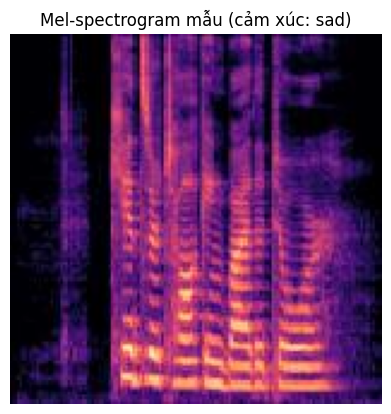

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from pathlib import Path

# Lấy đường dẫn đến một hình ảnh mẫu (ví dụ: cảm xúc 'happy')
# Đảm bảo thư mục 'happy' và các tệp .jpg tồn tại trước khi chạy

all_image_paths = []
image_dir = Path('data_images/train')

for emotion_folder in image_dir.iterdir():
    if emotion_folder.is_dir():
        all_image_paths.extend(list(emotion_folder.glob('*.jpg')))


if all_image_paths:
    sample_image_path = random.choice(all_image_paths)
    print(f"Hiển thị hình ảnh mẫu ngẫu nhiên từ: {sample_image_path}")
    img = mpimg.imread(sample_image_path)
    plt.imshow(img)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title(f"Mel-spectrogram mẫu (cảm xúc: {sample_image_path.parent.name})")
    plt.show()
else:
    print("Không tìm thấy hình ảnh nào để hiển thị. Vui lòng kiểm tra lại quá trình tạo ảnh.")

### Bước 3: Huấn luyện Model AI (FastAI)


/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,accuracy,time
0,3.075649,1.795261,0.395833,08:30


epoch,train_loss,valid_loss,accuracy,time
0,1.926046,1.572075,0.440972,11:31
1,1.445057,1.481736,0.493056,11:25
2,1.063187,1.402336,0.531250,11:26
3,0.760085,1.459659,0.520833,11:24
4,0.537094,1.549837,0.510417,11:24
5,0.387069,1.514144,0.555556,11:27
6,0.278715,1.498311,0.572917,11:22
7,0.199704,1.499590,0.586806,11:25
8,0.142021,1.463092,0.590278,11:26
9,0.102814,1.459049,0.586806,11:39


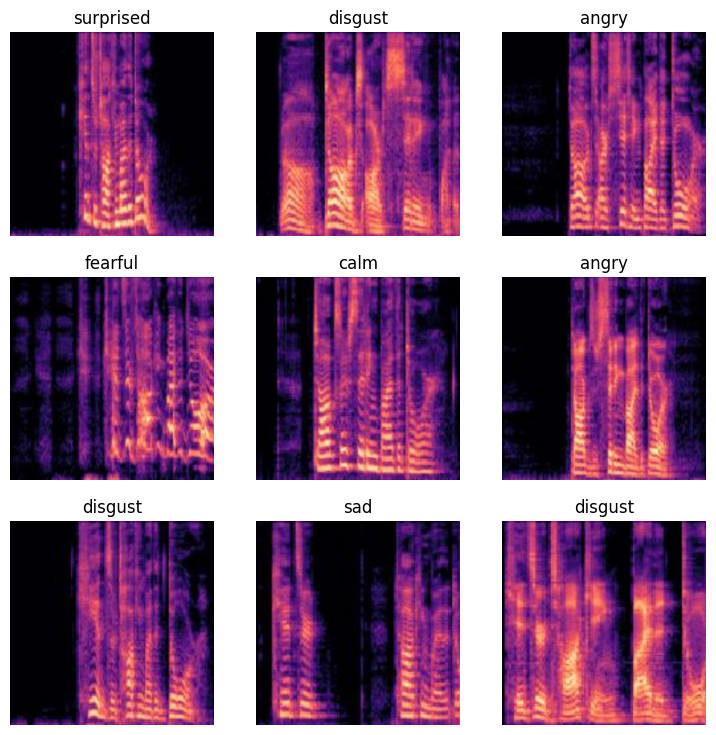

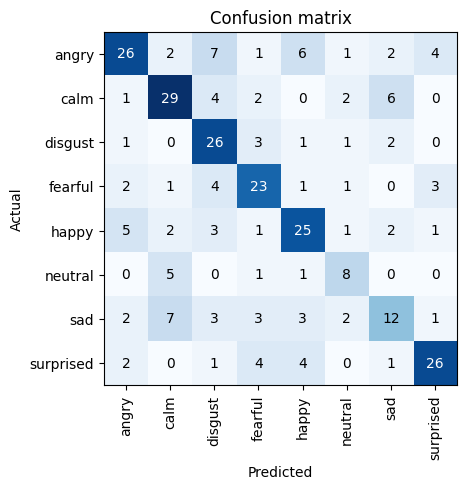

In [5]:
# Tạo DataLoaders
dls = ImageDataLoaders.from_folder(
    'data_images/train',
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224)
)

# Hiển thị mẫu dữ liệu
dls.show_batch(max_n=9)

# Tạo mô hình CNN (ResNet34)
learn = cnn_learner(dls, resnet34, metrics=accuracy)

# Tìm tốc độ học tối ưu và Train
learn.fine_tune(15) # Train 15 vòng

# Đánh giá bằng Confusion Matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

 lưu mô hình vào một thư mục bất kỳ trong Drive  lưu nó vào một thư mục tên là `colab_models` trong thư mục gốc của Drive.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

model_save_path = '/content/drive/MyDrive/colab_models/'
os.makedirs(model_save_path, exist_ok=True)

learn.export(f'{model_save_path}emotion_resnet34.pkl')
print(f"Mô hình đã được lưu tại: {model_save_path}emotion_resnet34.pkl")

Mô hình đã được lưu tại: /content/drive/MyDrive/colab_models/emotion_resnet34.pkl



### Bước 4: Test giọng nói trực tiếp trên Colab

Hãy nói điều gì đó biểu cảm...


<IPython.core.display.Javascript object>

Đã ghi âm xong!


/tmp/ipykernel_8895/2525672044.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, duration=3)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Kết quả dự đoán: FEARFUL
Độ tự tin: 98.80%


<Axes: >

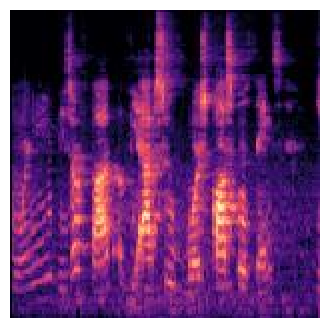

In [28]:
# Code JavaScript để thu âm trên trình duyệt Colab
from IPython.display import display, Javascript
from google.colab import output
import base64

def record_audio():
    js = Javascript("""
    async function recordAudio() {
      const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
      const mediaRecorder = new MediaRecorder(stream);
      let chunks = [];
      mediaRecorder.ondataavailable = (e) => chunks.push(e.data);
      mediaRecorder.start();
      await new Promise(r => setTimeout(r, 5000)); // Thu âm 3 giây
      mediaRecorder.stop();
      return new Promise(r => {
        mediaRecorder.onstop = () => {
          const blob = new Blob(chunks);
          const reader = new FileReader();
          reader.readAsDataURL(blob);
          reader.onloadend = () => r(reader.result.split(',')[1]);
        };
      });
    }
    """)
    display(js)
    data = output.eval_js('recordAudio()')
    with open('test_voice.wav', 'wb') as f:
        f.write(base64.b64decode(data))
    print("Đã ghi âm xong!")

# Chạy ghi âm và Dự đoán
print("Hãy nói điều gì đó biểu cảm...")
record_audio()

# Chuyển file vừa ghi thành ảnh để predict
create_spectrogram('test_voice.wav', 'test_voice.jpg')
img = PILImage.create('test_voice.jpg')
emotion_pred, _, probs = learn.predict(img)

print(f"\nKết quả dự đoán: {emotion_pred.upper()}")
print(f"Độ tự tin: {probs.max().item()*100:.2f}%")
img.show()
